In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report


Numberical Naive bayes

In [3]:

#  Numerical Gaussian Naive Bayes 
class GaussianNB:

    def fit(self, X, y):

        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:

            X_c = X[y == c]

            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)

            self.prior[c] = len(X_c) / len(X)


    def gaussian(self, class_idx, x):

        mean = self.mean[class_idx]
        var = self.var[class_idx]

        numo= np.exp(-(x-mean)**2 / (2*var))
        deno = np.sqrt(2*np.pi*var)

        return numo/ deno


    def predict(self, X):

        preds = []

        for x in X:

            posteriors = []

            for c in self.classes:

                prior = np.log(self.prior[c])

                likelihood = np.sum(np.log(self.gaussian(c, x)))

                posterior = prior + likelihood

                posteriors.append(posterior)

            preds.append(self.classes[np.argmax(posteriors)])

        return np.array(preds)

Categogrical Naive bayes

In [4]:

class CategoricalNB:

    def fit(self, X, y):

        self.classes = np.unique(y)
        self.prior = {}
        self.likelihood = {}

        for c in self.classes:

            X_c = X[y == c]

            self.prior[c] = len(X_c) / len(X)

            self.likelihood[c] = []

            for col in range(X.shape[1]):

                values, counts = np.unique(X_c[:,col], return_counts=True)

                prob = {}

                for v,count in zip(values,counts):
                    prob[v] = count / len(X_c)

                self.likelihood[c].append(prob)


    def predict(self, X):

        preds = []

        for x in X:

            probs = {}

            for c in self.classes:

                prob = self.prior[c]

                for i,value in enumerate(x):

                    if value in self.likelihood[c][i]:
                        prob *= self.likelihood[c][i][value]
                    else:
                        prob *= 1e-6

                probs[c] = prob

            preds.append(max(probs, key=probs.get))

        return np.array(preds)

PCA

In [54]:
def pca(Data, k):
    Data_mean = Data - np.mean(Data, axis=0)

    covariance_matrix = np.cov(Data_mean,rowvar=False)

    eig_values, eig_vectors = np.linalg.eig(covariance_matrix)

    eign_indexes = np.argsort(eig_values)[::-1]
    eigenvectors_sorted = eig_vectors[:,eign_indexes]

    selected_eigenvectors = eigenvectors_sorted[:, :k]

    transformed_data = np.dot(Data_mean, selected_eigenvectors)

    return transformed_data


In [47]:
df_num = pd.read_csv("survey lung cancer.csv")
df_num.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [48]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [49]:
df_num.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')

In [50]:

df_num['GENDER'] = df_num['GENDER'].map({'M': 0, 'F': 1})
df_num['LUNG_CANCER'] = df_num['LUNG_CANCER'].map({'NO': 0, 'YES': 1})
df_num_orig=df_num
df_num_orig.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,0,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,1,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,0,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,1,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [51]:
X1 = df_num.drop("LUNG_CANCER",axis=1).values
y1 = df_num["LUNG_CANCER"].values
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)


Gaussian NB (No PCA)

Gaussian Naive Bayes — Original Features (No PCA)
Accuracy: 0.9570

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.57      0.67         7
           1       0.97      0.99      0.98        86

    accuracy                           0.96        93
   macro avg       0.88      0.78      0.82        93
weighted avg       0.95      0.96      0.95        93

Confusion Matrix:
[[ 4  3]
 [ 1 85]]


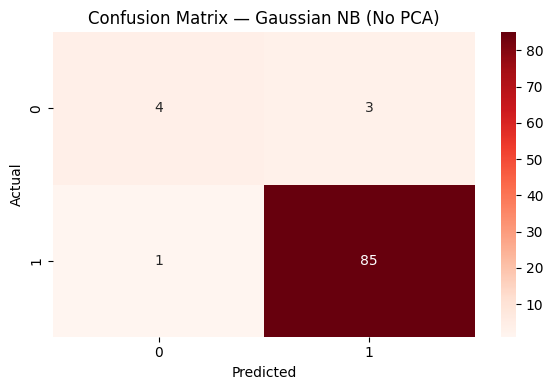

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train1, y_train1)
y_pred_full = gnb.predict(X_test1)

acc_full = accuracy_score(y_test1, y_pred_full)
cm_full = confusion_matrix(y_test1, y_pred_full)
cr_full = classification_report(y_test1, y_pred_full)

print("=" * 50)
print("Gaussian Naive Bayes — Original Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=gnb.classes, yticklabels=gnb.classes)
plt.title("Confusion Matrix — Gaussian NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

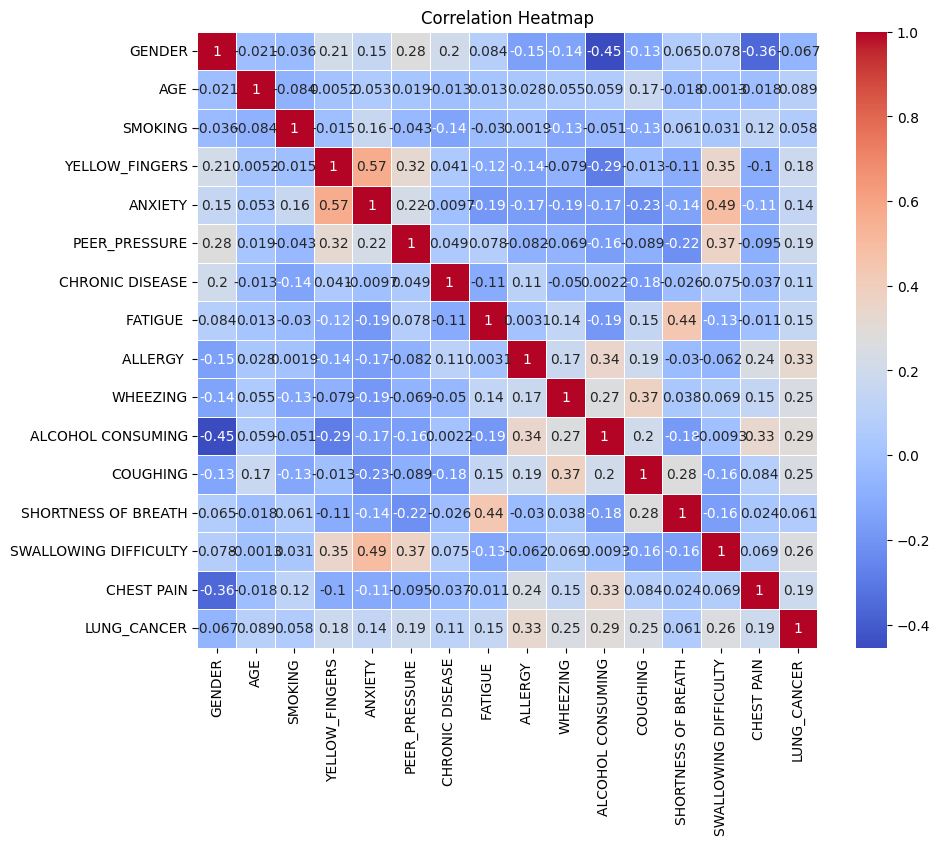

In [36]:
corr_matrix = df_num.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Feature Selection + Naive Bayes

In [39]:
df_num_orig.columns = df_num_orig.columns.str.lower().str.strip()

df_num_selected = df_num_orig[['allergy','alcohol consuming','coughing',
                               'swallowing difficulty','wheezing','lung_cancer']]

X1 = df_num_selected.drop("lung_cancer", axis=1).values
y1 = df_num_selected["lung_cancer"].values

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

Gaussian Naive Bayes — Original Features (No PCA)
Accuracy: 0.9355

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.57      0.57         7
           1       0.97      0.97      0.97        86

    accuracy                           0.94        93
   macro avg       0.77      0.77      0.77        93
weighted avg       0.94      0.94      0.94        93

Confusion Matrix:
[[ 4  3]
 [ 3 83]]


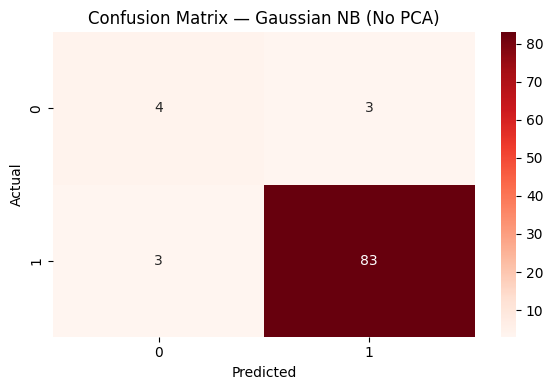

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train1, y_train1)
y_pred_full = gnb.predict(X_test1)

acc_full = accuracy_score(y_test1, y_pred_full)
cm_full = confusion_matrix(y_test1, y_pred_full)
cr_full = classification_report(y_test1, y_pred_full)

print("=" * 50)
print("Gaussian Naive Bayes — Original Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=gnb.classes, yticklabels=gnb.classes)
plt.title("Confusion Matrix — Gaussian NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [57]:
results_pca = []

k_values = [1,2,3, 4, 5, 6, 7, 8, 9, 10,11,12,13]

for k in k_values:
    X_train_pca = pca(X_train1, k)
    X_test_pca = pca(X_test1, k)
    
    gnb_pca = GaussianNB()
    gnb_pca.fit(X_train_pca, y_train1)
    
    y_pred_pca = gnb_pca.predict(X_test_pca)
    
    acc_pca = accuracy_score(y_test1, y_pred_pca)
    
    results_pca.append({
        'k': k,
        'Accuracy': acc_pca
    })
    
    print(f"k={k}: Accuracy = {acc_pca:.4f}")



best_result = max(results_pca, key=lambda x: x['Accuracy'])
best_k = best_result['k']
best_acc = best_result['Accuracy']

print("\n" + "=" * 50)
print(f"BEST k = {best_k} with Accuracy = {best_acc:.4f}")
print("=" * 50)

k=1: Accuracy = 0.9247
k=2: Accuracy = 0.9247
k=3: Accuracy = 0.9032
k=4: Accuracy = 0.8925
k=5: Accuracy = 0.8817
k=6: Accuracy = 0.8602
k=7: Accuracy = 0.8710
k=8: Accuracy = 0.8710
k=9: Accuracy = 0.8817
k=10: Accuracy = 0.8710
k=11: Accuracy = 0.8710
k=12: Accuracy = 0.8817
k=13: Accuracy = 0.8925

BEST k = 1 with Accuracy = 0.9247


Cateorigal dataset

In [67]:
df_cat = pd.read_csv("iris_flower_categorical.csv")
df_cat.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,Short,Wide,Short,Narrow,setosa
1,Short,Medium,Short,Narrow,setosa
2,Short,Medium,Short,Narrow,setosa
3,Short,Medium,Short,Narrow,setosa
4,Short,Wide,Short,Narrow,setosa


In [68]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sepal_length  150 non-null    object
 1   sepal_width   150 non-null    object
 2   petal_length  150 non-null    object
 3   petal_width   150 non-null    object
 4   species       150 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


In [69]:
print(df_cat['sepal_length'].unique())
print(df_cat['sepal_width'].unique())
print(df_cat['petal_length'].unique())
print(df_cat['petal_width'].unique())
print(df_cat['species'].unique())


['Short' 'Medium' 'Long']
['Wide' 'Medium' 'Narrow']
['Short' 'Medium' 'Long']
['Narrow' 'Medium' 'Wide']
['setosa' 'versicolor' 'virginica']


In [70]:
df_cat['sepal_length'] = df_cat['sepal_length'].map({'Short': 0, 'Medium': 1, 'Long': 2})
df_cat['sepal_width'] = df_cat['sepal_width'].map({'Narrow': 0, 'Medium': 1, 'Wide': 2})
df_cat['petal_length'] = df_cat['petal_length'].map({'Short': 0, 'Medium': 1, 'Long': 2})
df_cat['petal_width'] = df_cat['petal_width'].map({'Narrow': 0, 'Medium': 1, 'Wide': 2})
df_cat['species'] = df_cat['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2})
df_cat.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,0,2,0,0,0
1,0,1,0,0,0
2,0,1,0,0,0
3,0,1,0,0,0
4,0,2,0,0,0


In [84]:
X1 = df_cat.drop("species",axis=1).values
y1 = df_cat["species"].values
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)


Gussian NB (NO PCA)

Gaussian Naive Bayes — Original Features (No PCA)
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


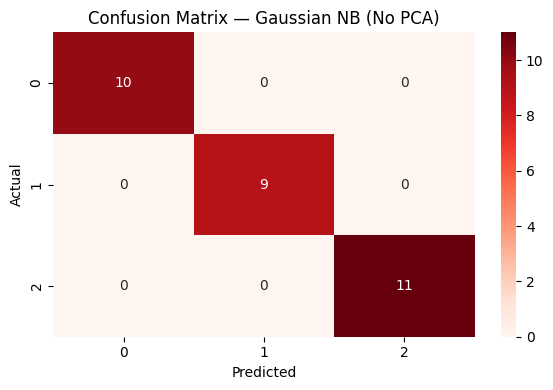

In [83]:
# ...existing code...
cnb = CategoricalNB()
cnb.fit(X_train1, y_train1)
y_pred_cat = cnb.predict(X_test1)


acc_full = accuracy_score(y_test1, y_pred_cat)
cm_full = confusion_matrix(y_test1, y_pred_cat)
cr_full = classification_report(y_test1, y_pred_cat)

print("=" * 50)
print("Gaussian Naive Bayes — Original Features (No PCA)")
print("=" * 50)
print(f"Accuracy: {acc_full:.4f}")
print("\nClassification Report:")
print(cr_full)
print("Confusion Matrix:")
print(cm_full)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
            xticklabels=gnb.classes, yticklabels=gnb.classes)
plt.title("Confusion Matrix — Gaussian NB (No PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

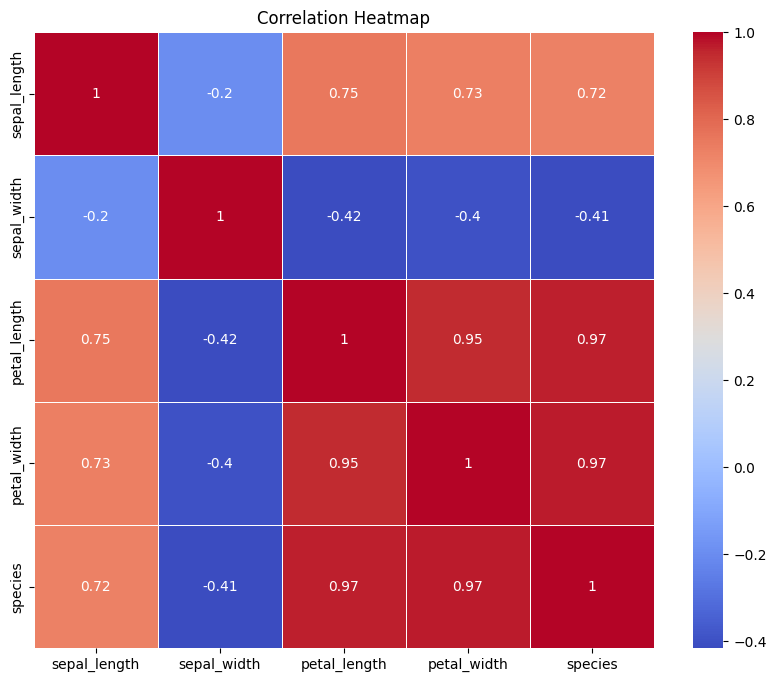

In [73]:
corr_matrix = df_cat.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:

# df_cat_selected = df_cat[['petal_length','petal_width','species']]

# X1 = df_cat_selected.drop("species", axis=1).values
# y1 = df_cat_selected["species"].values

# X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

C:\Users\Shadow\AppData\Local\Temp\ipykernel_25980\3891665558.py:26: RuntimeWarning: divide by zero encountered in divide
  numo= np.exp(-(x-mean)**2 / (2*var))
C:\Users\Shadow\AppData\Local\Temp\ipykernel_25980\3891665558.py:29: RuntimeWarning: invalid value encountered in divide
  return numo/ deno
C:\Users\Shadow\AppData\Local\Temp\ipykernel_25980\3891665558.py:26: RuntimeWarning: invalid value encountered in divide
  numo= np.exp(-(x-mean)**2 / (2*var))
C:\Users\Shadow\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shadow\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\P

Gaussian Naive Bayes — Original Features (No PCA)
Accuracy: 0.4222

Classification Report:
              precision    recall  f1-score   support

           0       0.42      1.00      0.59        19
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        13

    accuracy                           0.42        45
   macro avg       0.14      0.33      0.20        45
weighted avg       0.18      0.42      0.25        45

Confusion Matrix:
[[19  0  0]
 [13  0  0]
 [13  0  0]]


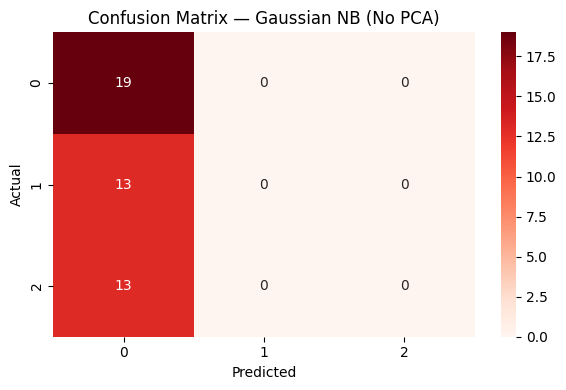

In [79]:
# gnb = GaussianNB()
# gnb.fit(X_train1, y_train1)
# y_pred_full = gnb.predict(X_test1)

# acc_full = accuracy_score(y_test1, y_pred_full)
# cm_full = confusion_matrix(y_test1, y_pred_full)
# cr_full = classification_report(y_test1, y_pred_full)

# print("=" * 50)
# print("Gaussian Naive Bayes — Original Features (No PCA)")
# print("=" * 50)
# print(f"Accuracy: {acc_full:.4f}")
# print("\nClassification Report:")
# print(cr_full)
# print("Confusion Matrix:")
# print(cm_full)

# plt.figure(figsize=(6, 4))
# sns.heatmap(cm_full, annot=True, fmt="d", cmap="Reds",
#             xticklabels=gnb.classes, yticklabels=gnb.classes)
# plt.title("Confusion Matrix — Gaussian NB (No PCA)")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.tight_layout()
# plt.show()